In [1]:
# ── Cell 2
# Core utilities
import os
import time
import warnings
import random
from argparse import Namespace

# Data & Numerical Computing
import numpy as np

# Plotting & Visualization
import matplotlib.pyplot as plt

# JAX Framework
import jax
import jax.numpy as jnp
from jax import random as jax_random


# ─────────────────────────────────────────────────────────────────────────────
# Global Configuration & Seeding
# ─────────────────────────────────────────────────────────────────────────────

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')

# Global JAX random key (used across all cells, including main())
JAX_KEY = None

def seed_everything(seed=42):
    """Set global seed for reproducibility across NumPy, Python random, and JAX."""
    global JAX_KEY
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    JAX_KEY = jax_random.PRNGKey(seed)

# Initialize global seed (this JAX_KEY will be used in main() function)
seed_everything(42)

def rk4_step(q, dynamics_fn, dt):
    """Perform a single RK4 integration step.

    Args:
        q: Current state
        dynamics_fn: Function that computes state derivatives
        dt: Time step

    Returns:
        q_new: Updated state after RK4 step
        deriv: Derivative at current state
    """
    k1 = dynamics_fn(q)
    k2 = dynamics_fn(q + 0.5 * dt * k1)
    k3 = dynamics_fn(q + 0.5 * dt * k2)
    k4 = dynamics_fn(q + dt * k3)

    q_new = q + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    deriv = dynamics_fn(q)  # Derivative at current state

    return q_new, deriv

# ─────────────────────────────────────────────────────────────────────────────
# JIGSAWS Dataset Directory Resolution
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path

# 1. Safely mount Google Drive ONLY if running in Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # Ignores the error if running on Kaggle or locally

# 2. Define potential paths using modern pathlib syntax (cleaner than os.path.join)
cwd = Path.cwd()
candidates = [
    Path('/content/drive/MyDrive/JIGSAWS/Suturing/Suturing'),
    cwd / 'JIGSAWS_datasets' / 'JIGSAWS' / 'Suturing' / 'Suturing',
    cwd / 'JIGSAWS' / 'Suturing' / 'Suturing',
    cwd / 'Suturing' / 'Suturing'
]

# 3. Find the first valid directory using a clean generator expression
JIGSAWS_ROOT = next((path for path in candidates if path.is_dir()), None)

if JIGSAWS_ROOT is None:
    raise FileNotFoundError("Could not find JIGSAWS_ROOT in any candidate paths.")

print(f'JIGSAWS_ROOT = {JIGSAWS_ROOT}')

# ─────────────────────────────────────────────────────────────
print('✓ All required libraries imported and configured.')

Mounted at /content/drive
JIGSAWS_ROOT = /content/drive/MyDrive/JIGSAWS/Suturing/Suturing
✓ All required libraries imported and configured.


In [2]:
# ── Cell 3 ·
# JIGSAWS data-loading utilities — interaction-only ──────────────
import numpy as np
import jax.numpy as jnp
from jax import jit
from pathlib import Path

global H_DATA_GEN
DT = 1.0 / 30.0  # 30 Hz
H_DATA_GEN = DT
FPS = 30

# ── Hand-annotated needle-tissue interaction intervals (seconds) ──────────────
INTERACTION_TIMES = {
    'B001': [(0,10),(23,32),(38,47),(60,79),(92,102),(124,135),(147,160),(169,180)],
    'B002': [(20,30),(47,60),(70,90),(100,109)],
    'B003': [(1,5),(10,20),(34,43),(52,70),(80,100)],
    'B004': [(5,25),(38,49),(59,75),(89,100)],
    'B005': [(16,34),(42,50),(62,72),(79,87)],
    'C001': [(13,26),(44,57),(70,76),(87,94)],
    'C002': [(15,28),(43,50),(63,71),(82,95)],
    'C003': [(15,24),(38,45),(56,65),(75,85),(100,102)],
    'C004': [(10,17),(29,37),(48,54),(63,70)],
    'C005': [(9,14),(23,30),(45,52),(59,74)],
    'D001': [(13,19),(38,52),(63,70),(78,88)],
    'D002': [(6,14),(24,31),(40,45),(54,62)],
    'D003': [(9,16),(25,33),(48,54),(60,73)],
    'D004': [(11,17),(26,31),(47,54),(77,83)],
    'D005': [(9,15),(23,29),(37,43),(50,55)],
    'E001': [(9,23),(25,32),(62,74),(89,98)],
    'E002': [(9,23),(36,44),(54,61),(70,80)],
    'E003': [(9,17),(24,33),(44,51),(62,69)],
    'E004': [(8,20),(30,39),(50,58),(74,82)],
    'E005': [(5,14),(24,32),(41,49),(58,64)],
    'F001': [(9,18),(32,40),(49,58),(71,81)],
    'F002': [(6,15),(26,35),(45,52),(59,68)],
    'F003': [(8,14),(23,24),(41,48),(56,62)],
    'F004': [(7,15),(23,29),(43,53),(63,69)],
    'F005': [(4,14),(22,26),(37,41),(51,57)],
    'G001': [(17,29),(49,85),(91,107),(121,146),(162,193),(211,292)],
    'G002': [(10,20),(29,45),(55,63),(74,103)],
    'G003': [(17,29),(38,47),(58,65),(92,112),(152,164)],
    'G004': [(16,24),(34,41),(50,58),(70,77)],
    'G005': [(8,17),(26,33),(41,55),(64,72)],
    'H001': [(24,51),(67,81),(128,135),(152,164)],
    'H003': [(18,33),(50,58),(71,83),(94,101)],
    'H004': [(15,24),(44,55),(80,91),(111,121)],
    'H005': [(14,24),(35,39),(88,91),(92,101)],
    'I001': [(16,31),(45,57),(72,85),(119,132)],
    'I002': [(22,42),(58,81),(100,112),(127,142)],
    'I003': [(27,44),(58,79),(99,116),(127,135)],
    'I004': [(18,37),(50,64),(84,98),(111,118)],
    'I005': [(22,42),(58,68),(83,96),(110,124)],
}

def make_mask(trial_key, num_frames, fps=FPS):
    """Bool mask (T,): True = needle-tissue interaction frame."""
    mask = np.zeros(num_frames, dtype=bool)
    for (t0, t1) in INTERACTION_TIMES.get(trial_key, []):
        f0, f1 = max(0, int(round(t0 * fps))), min(num_frames - 1, int(round(t1 * fps)))
        mask[f0:f1 + 1] = True
    return mask

def _contiguous_segments(mask):
    """List of (start, end) frame-index pairs for each True run in mask."""
    # Cleaner state tracking
    diffs = np.diff(np.concatenate([[0], mask.view(np.int8), [0]]))
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]
    return list(zip(starts, ends))

def _parse_meta(meta_path):
    with open(meta_path) as fh:
        return {p[0]: p[1] for line in fh if len(p := line.strip().split()) >= 2}

@jit
def _rotmat_to_rotvec_batch_jax(R):
    """Convert batch of 3x3 rotation matrices to axis-angle rotation vectors (JAX Compiled)."""
    tr = jnp.trace(R, axis1=1, axis2=2)
    cos_th = jnp.clip((tr - 1.0) * 0.5, -1.0, 1.0)
    th = jnp.arccos(cos_th)

    v = jnp.stack([
        R[:, 2, 1] - R[:, 1, 2],
        R[:, 0, 2] - R[:, 2, 0],
        R[:, 1, 0] - R[:, 0, 1],
    ], axis=1)

    # JAX arrays are immutable, so we use jnp.where instead of boolean array assignments
    small_angle_mask = (th < 1e-6)[:, None]

    s = jnp.sin(th)[:, None]
    axis = v / jnp.clip(2.0 * s, 1e-8, None)

    rv_small = 0.5 * v  # First-order approximation near zero
    rv_large = axis * th[:, None]

    return jnp.where(small_angle_mask, rv_small, rv_large)

def _load_trial_file(path):
    arr = np.loadtxt(path, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 56:
        raise ValueError(f'Unexpected kinematics shape {arr.shape} in {path}')

    # Send values to JAX
    pos     = jnp.array(arr[:, 38:41])
    R       = jnp.array(arr[:, 41:50]).reshape(-1, 3, 3)
    rotvec  = _rotmat_to_rotvec_batch_jax(R)
    lin_vel = jnp.array(arr[:, 50:53])
    ang_vel = jnp.array(arr[:, 53:56])

    q     = jnp.concatenate([pos, rotvec], axis=-1)   # (T,6)
    q_dot = jnp.concatenate([lin_vel, ang_vel], axis=-1)
    return q, q_dot

def load_suturing_interaction(root, skill=None, subjects=None):
    root_path = Path(root)
    meta = _parse_meta(root_path / 'meta_file_Suturing.txt')
    kin_dir = root_path / 'kinematics' / 'AllGestures'

    trials = []
    # Using pathlib.glob for cleaner directory parsing
    for file_path in sorted(kin_dir.glob('*.txt')):
        name = file_path.stem
        sk = meta.get(name)
        if not sk:
            continue

        subj = name.split('_')[-1][0]
        if (subjects and subj not in subjects) or (skill and sk != skill):
            continue

        q, qd = _load_trial_file(file_path)
        states = jnp.concatenate([q, qd], axis=-1)

        trial_key = name.replace('Suturing_', '')
        mask = make_mask(trial_key, len(states))

        for si, (s, e) in enumerate(_contiguous_segments(mask)):
            seg = states[s:e]
            if len(seg) >= 2:
                trials.append({
                    'name': f'{name}_s{si:02d}', 'subject': subj, 'skill': sk,
                    'states': seg, 'length': len(seg), 'trial': name, 'seg_idx': si
                })
    return trials

def build_transitions(trials):
    """One-step transitions from segmented trials: (x_t, x_{t+1})."""
    xt   = jnp.concatenate([t['states'][:-1] for t in trials], axis=0)
    xtp1 = jnp.concatenate([t['states'][1:] for t in trials], axis=0)
    return xt, xtp1

def build_sequences(trials, K=5):
    """K-step sequences for rollout curriculum using list comprehensions."""
    xs, ys = [], []
    for t in trials:
        s = t['states']
        T_ = len(s)
        xs.extend([s[i] for i in range(T_ - K)])
        ys.extend([s[i + 1 : i + K + 1] for i in range(T_ - K)])

    return jnp.array(xs), jnp.array(ys)

print('✓ Interaction-only data utilities compiled in JAX (6-DOF).')

✓ Interaction-only data utilities compiled in JAX (6-DOF).


In [20]:
# ── Cell 4: Generate Data & LOUO Split (TRAIN = EXPERT) ──────────────
LOUO_TEST_SUBJECT = None  # None defaults to the last expert subject

print('Loading JIGSAWS Suturing — INTERACTION segments only ...')

# 1. Load segments
nov_segs = sorted(load_suturing_interaction(JIGSAWS_ROOT, skill='N'), key=lambda x: x['name'])
exp_segs = sorted(load_suturing_interaction(JIGSAWS_ROOT, skill='E'), key=lambda x: x['name'])

# 2. Extract unique expert subjects
expert_subjects = sorted({s['subject'] for s in exp_segs})
test_subject = LOUO_TEST_SUBJECT or expert_subjects[-1]

# 3. LOUO split on EXPERTS
exp_train = [s for s in exp_segs if s['subject'] != test_subject]
exp_test  = [s for s in exp_segs if s['subject'] == test_subject]

# 4. Build JAX Arrays (Keeping x_tr variable name so training cell doesn't break)
x_tr, y_tr = build_transitions(exp_train)
x_test_in, y_test_in = build_transitions(exp_test)        # Expert test (In-distribution)
x_test_ood, y_test_ood = build_transitions(nov_segs)      # Novice test (Out-of-distribution)

# 5. Output summary
print('\n✓ JIGSAWS Suturing Data (Train=Expert, OOD=Novice):')
print(f"  Split Subject: '{test_subject}' (Expert Leave-One-User-Out)")
print(f"  Train (Expert) : {x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/FPS:>6.1f}s")
print(f"  Test (Expert)  : {x_test_in.shape[0]:>6,} transitions | {x_test_in.shape[0]/FPS:>6.1f}s")
print(f"  Test (Novice)  : {x_test_ood.shape[0]:>6,} transitions | {x_test_ood.shape[0]/FPS:>6.1f}s")

Loading JIGSAWS Suturing — INTERACTION segments only ...

✓ JIGSAWS Suturing Data (Train=Expert, OOD=Novice):
  Split Subject: 'E' (Expert Leave-One-User-Out)
  Train (Expert) :  4,380 transitions |  146.0s
  Test (Expert)  :  5,400 transitions |  180.0s
  Test (Novice)  : 34,950 transitions | 1165.0s


In [22]:
# ── Cell 5
# Dataset comparison: Full vs Interaction-only ───────────────────
from collections import defaultdict
from pathlib import Path

root_path = Path(JIGSAWS_ROOT)
kin_dir   = root_path / 'kinematics' / 'AllGestures'
meta_full = _parse_meta(root_path / 'meta_file_Suturing.txt')

full_counts = defaultdict(lambda: {'trials': 0, 'frames': 0})
int_counts  = defaultdict(lambda: {'trials': 0, 'segs': 0, 'frames': 0})

# ─────────────────────────────────────────────────────────────────────────────
# 1. Full dataset stats (Optimized: Avoids loading entire matrices into memory)
# ─────────────────────────────────────────────────────────────────────────────
def count_lines(filepath):
    """Counts file lines generator-style without loading data into memory."""
    with open(filepath, 'r') as f:
        return sum(1 for _ in f)

for file_path in kin_dir.glob('*.txt'):
    sk = meta_full.get(file_path.stem)
    if sk:
        full_counts[sk]['trials'] += 1
        full_counts[sk]['frames'] += count_lines(file_path)

# ─────────────────────────────────────────────────────────────────────────────
# 2. Interaction-only stats (from already-loaded segments)
# ─────────────────────────────────────────────────────────────────────────────
all_segs = load_suturing_interaction(JIGSAWS_ROOT)

for sk in ['E', 'I', 'N']:
    sk_segs = [s for s in all_segs if s['skill'] == sk]
    int_counts[sk]['trials'] = len({s['trial'] for s in sk_segs}) # Set comprehension
    int_counts[sk]['segs']   = len(sk_segs)
    int_counts[sk]['frames'] = sum(s['length'] for s in sk_segs)

# ─────────────────────────────────────────────────────────────────────────────
# 3. Print Comparison Table
# ─────────────────────────────────────────────────────────────────────────────
W = 76
print('=' * W)
print('  DATASET COMPARISON — Full recording vs Needle-tissue Interaction only')
print('=' * W)
print(f'  {"Skill":<5}  {"───── Full dataset ──────────":29}  {"───── Interaction only ────────────":38}')
print(f'  {"":5}  {"Trials":>6}  {"Frames":>8}  {"Duration":>10}  '
      f'{"Trials":>6}  {"Segs":>5}  {"Frames":>8}  {"Duration":>10}  {"Kept %":>7}')
print('  ' + '-' * (W - 2))

total_full, total_int = 0, 0
for sk in ['E', 'I', 'N']:
    fc, ic = full_counts[sk], int_counts[sk]
    pct = 100.0 * ic['frames'] / max(fc['frames'], 1)

    total_full += fc['frames']
    total_int  += ic['frames']

    print(f"  {sk:<5}  {fc['trials']:>6}  {fc['frames']:>8,}  {fc['frames']/FPS:>9.1f}s  "
          f"{ic['trials']:>6}  {ic['segs']:>5}  {ic['frames']:>8,}  {ic['frames']/FPS:>9.1f}s  {pct:>6.1f}%")

print('  ' + '-' * (W - 2))
pct_tot = 100.0 * total_int / max(total_full, 1)
print(f"  {'ALL':<5}  {'':>6}  {total_full:>8,}  {total_full/FPS:>9.1f}s  "
      f"{'':>6}  {'':>5}  {total_int:>8,}  {total_int/FPS:>9.1f}s  {pct_tot:>6.1f}%")
print('=' * W)

# ─────────────────────────────────────────────────────────────────────────────
# 4. LOUO Split Stats (Uses JAX array shapes from Cell 4)
# ─────────────────────────────────────────────────────────────────────────────
longest  = max(exp_train, key=lambda t: t['length'])
shortest = min(exp_train, key=lambda t: t['length'])

train_subjects = sorted({s['subject'] for s in exp_train})

print(f'\n── LOUO split (interaction frames) ──')
print(f'  Train subjects : {train_subjects} → {len(exp_train):2d} segs | '
      f'{x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/FPS:>6.1f}s')
print(f'  Test subject   : {test_subject}             → {len(exp_test):2d} segs | '
      f'{x_test_in.shape[0]:>6,} transitions | {x_test_in.shape[0]/FPS:>6.1f}s')
print(f'  Novice (OOD)   :                {len(nov_segs):2d} segs | '
      f'{x_test_ood.shape[0]:>6,} transitions | {x_test_ood.shape[0]/FPS:>6.1f}s')

print(f'  Longest train seg : {longest["name"]:22s}  {longest["length"]:4d} frames = {longest["length"]/FPS:.1f}s')
print(f'  Shortest train seg: {shortest["name"]:22s}  {shortest["length"]:4d} frames = {shortest["length"]/FPS:.1f}s')

  DATASET COMPARISON — Full recording vs Needle-tissue Interaction only
  Skill  ───── Full dataset ──────────  ───── Interaction only ────────────   
         Trials    Frames    Duration  Trials   Segs    Frames    Duration   Kept %
  --------------------------------------------------------------------------
  E          10    26,407      880.2s      10     40     9,820      327.3s    37.2%
  I          10    26,554      885.1s      10     41     9,731      324.4s    36.6%
  N          19    78,417     2613.9s      19     84    35,034     1167.8s    44.7%
  --------------------------------------------------------------------------
  ALL             131,378     4379.3s                   54,585     1819.5s    41.5%

── LOUO split (interaction frames) ──
  Train subjects : ['D'] → 20 segs |  4,380 transitions |  146.0s
  Test subject   : E             → 20 segs |  5,400 transitions |  180.0s
  Novice (OOD)   :                84 segs | 34,950 transitions | 1165.0s
  Longest train seg : S

In [23]:
# ── Cell 6 ───────────────────────────────────────────────────────────────────
import jax
import jax.numpy as jnp
import flax.linen as nn

class LSTMPredictor(nn.Module):
    """
    Seq-to-next-state LSTM for JIGSAWS kinematics in JAX/Flax.

    Input  : s_t  (B, 12) - normalised [q(6), q_dot(6)]
    Output : s_{t+1}_pred (B, 12) - normalised predicted next state
    """
    hidden_size: int = 256
    num_layers: int = 2
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x, carry=None, deterministic: bool = True):
        # x: (B, 12) single-step state
        batch_size = x.shape[0]

        # Initialize default zero carry if none provided
        if carry is None:
            # FIX: initialize_carry only takes (rng, batch_dims)
            carry = [nn.LSTMCell(features=self.hidden_size).initialize_carry(
                        jax.random.PRNGKey(0), (batch_size,))
                     for _ in range(self.num_layers)]

        new_carry = []
        hidden_out = x

        # Chain LSTM cells with dropout
        for i in range(self.num_layers):
            c, h = carry[i]
            (new_c, new_h), hidden_out = nn.LSTMCell(features=self.hidden_size)( (c, h), hidden_out )
            new_carry.append((new_c, new_h))

            # Match PyTorch LSTM dropout: applied to the output of each LSTM layer except the last
            if i < self.num_layers - 1:
                hidden_out = nn.Dropout(rate=self.dropout_rate, deterministic=deterministic)(hidden_out)

        # Residual MLP Head: 256 → 128 → 64 → 12
        delta = nn.Dense(128)(hidden_out)
        delta = nn.gelu(delta)
        delta = nn.Dense(64)(delta)
        delta = nn.gelu(delta)
        delta = nn.Dense(x.shape[-1])(delta)

        return x + delta, new_carry

print("✓ LSTM Architecture defined in JAX/Flax.")

✓ LSTM Architecture defined in JAX/Flax.


In [24]:
# ── Cell 7 ───────────────────────────────────────────────────────────────────
import optax
import time
import numpy as np
from argparse import Namespace
from functools import partial
import flax.traverse_util as traverse_util

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  Loss & Optimization (JAX) ──────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def loss_fn(params, model, xb, yb, delta_scale, l2_coef, l1_coef, dropout_key):
    """
    Computes the single-step (K=1) loss for the LSTM model.
    """
    # 1. Forward pass (Flax apply requires rngs for dropout)
    # Using carry=None automatically initializes zeros inside the model definition
    preds, _ = model.apply(params, xb, deterministic=False, rngs={'dropout': dropout_key})

    # 2. MSE (Normalized)
    errors = ((preds - yb) / delta_scale)**2
    base_loss = jnp.mean(errors)

    # 3. Global L2 Regularization
    l2_reg = sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

    # 4. Targeted L1 Regularization (Applies ONLY if a force_combiner layer exists - safely 0 for LSTM)
    flat_params = traverse_util.flatten_dict(params, sep='/')
    l1_reg = 0.0
    for path, weight in flat_params.items():
        if 'force_combiner' in path and 'kernel' in path:
            l1_reg += jnp.sum(jnp.abs(weight))

    # 5. Final optimization target
    total_loss = base_loss + (l2_coef * l2_reg) + (l1_coef * l1_reg)

    # Return as an array of shape (1,) so the logging print string `sys_losses` still works
    return total_loss, jnp.array([base_loss])

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── JIT Compiled Update Step ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@partial(jax.jit, static_argnames=['model', 'tx'])
def update_step(model, tx, params, opt_state, xb, yb, delta_scale, l2_coef, l1_coef, dropout_key):
    """Calculates gradients, updates optimizer, and returns new params in a pure function."""
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    # Pass the keys to the gradient function
    (total_loss, system_losses), grads = grad_fn(
        params, model, xb, yb, delta_scale, l2_coef, l1_coef, dropout_key
    )

    # Optimizer step
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Training Loop ────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def train_loop(model, tx, params, opt_state, iter_count, Xs, Ys, delta_scale, key, training_start, batch_size):
    max_idx = len(Xs) - 1
    key, subkey = jax.random.split(key)
    start_idxs = jax.random.randint(subkey, (batch_size,), 0, max_idx)

    xb = Xs[start_idxs]
    yb = Ys[start_idxs]

    # Optimization Step
    key, dropout_key = jax.random.split(key)
    params, opt_state, total_loss, sys_losses = update_step(
        model, tx, params, opt_state, xb, yb, delta_scale, 1e-5, 1e-5, dropout_key
    )

    if iter_count % 500 == 0:
        total_loss.block_until_ready()
        total_elapsed = time.perf_counter() - training_start
        # Format individual system losses for printing
        sys_loss_str = ", ".join([f"{l:.2e}" for l in sys_losses])
        print(
            f"[Iter {iter_count:5d}] "
            f"Comb_Loss: {total_loss:.2e} | "
            f"Sys MSEs: [{sys_loss_str}] | "
            f"Total Time: {total_elapsed/60:.2f} min"
        )

    iter_count += 1
    return params, opt_state, total_loss, iter_count, key

def main(args, Xs_raw, Ys_raw):
    print(f'Device: {jax.devices()[0]}')

    # Ensure inputs are normalized internally to preserve metric scale
    state_mean_np = np.mean(Xs_raw, axis=0, keepdims=True)
    state_std_np = np.clip(np.std(Xs_raw, axis=0, keepdims=True), 1e-8, None)

    x_tr_n = (Xs_raw - state_mean_np) / state_std_np
    y_tr_n = (Ys_raw - state_mean_np) / state_std_np

    delta_tr_n = y_tr_n - x_tr_n
    delta_scale_np = np.clip(np.std(delta_tr_n, axis=0, keepdims=True), 1e-6, None)

    # Cast to JAX arrays
    Xs = jnp.array(x_tr_n, dtype=jnp.float32)
    Ys = jnp.array(y_tr_n, dtype=jnp.float32)
    delta_scale_jax = jnp.array(delta_scale_np, dtype=jnp.float32)

    # 1. Initialize Batched Model State
    model = LSTMPredictor(hidden_size=256, num_layers=2, dropout_rate=0.1)

    key = jax.random.PRNGKey(42)
    key, init_key = jax.random.split(key)

    # State size is 12 (q(6) + q_dot(6))
    dummy_x = jnp.ones((args.batch_size, args.dimension * 2))
    params = model.init(init_key, dummy_x)

    loss_history = []
    global_iter = 1
    training_start = time.perf_counter()

    print(f'\n{"="*80}')
    print(f'{"STARTING LSTM TRAINING (K=1)":^80}')
    print(f'{"="*80}')

    # ── STAGE 1: WARMUP (Linear Learning Rate) ──────────────────────────
    print(f'Stage 1: Warmup ({args.iterations_1} iterations)')

    schedule1 = optax.linear_schedule(
        init_value=args.lr * 0.1,
        end_value=args.lr,
        transition_steps=args.iterations_1
    )
    tx1 = optax.chain(
        optax.clip_by_global_norm(10.0), # 10.0 is generally standard for LSTM clipping
        optax.adamw(learning_rate=schedule1, weight_decay=args.weight_decay)
    )
    opt_state1 = tx1.init(params)

    for step in range(args.iterations_1):
        params, opt_state1, avg_loss, global_iter, key = train_loop(
            model, tx1, params, opt_state1, global_iter, Xs, Ys, delta_scale_jax, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    # ── STAGE 2: FINE-TUNING (Cosine Annealing) ─────────────────────────
    print(f'Stage 2: Fine-tuning ({args.iterations_2} iterations)')
    schedule2 = optax.cosine_decay_schedule(init_value=args.lr, decay_steps=args.iterations_2)
    tx2 = optax.chain(
        optax.clip_by_global_norm(10.0),
        optax.adamw(learning_rate=schedule2, weight_decay=args.weight_decay)
    )
    opt_state2 = tx2.init(params)

    for step in range(args.iterations_2):
        params, opt_state2, avg_loss, global_iter, key = train_loop(
            model, tx2, params, opt_state2, global_iter, Xs, Ys, delta_scale_jax, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    print(f'\n✅ Model Training complete.')
    return np.array(loss_history), params, model, state_mean_np, state_std_np, delta_scale_np

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── TRAINING EXECUTION (JAX) ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Create training configuration
args = Namespace(
    dimension=6,         # Degrees of freedom (d=6 means state size is 12: q, q_dot)
    lr=3e-4,             # Peak learning rate
    iterations_1=3000,   # Warmup steps
    iterations_2=3000,   # Fine-tuning steps
    batch_size=512,
    weight_decay=1e-5,
    pt_dir='./models'
)

# Execute training (Make sure x_tr and y_tr are loaded/defined prior to running this)
training_start = time.perf_counter()

loss_arr, final_params, dnn, state_mean, state_std, delta_scale = main(args, x_tr, y_tr)

total_time = time.perf_counter() - training_start

print(f'{"="*80}')
print(f'Training complete in {total_time/60:.2f} minutes.')
print(f'Model object is available as `dnn`.')
print(f'Model weights are available as `final_params`.')
print(f'Loss history available as `loss_arr` ({len(loss_arr)} points).')
print(f'{"="*80}\n')

Device: cuda:0

                          STARTING LSTM TRAINING (K=1)                          
Stage 1: Warmup (3000 iterations)
[Iter   500] Comb_Loss: 7.20e-01 | Sys MSEs: [6.89e-01] | Total Time: 0.17 min
[Iter  1000] Comb_Loss: 5.84e-01 | Sys MSEs: [5.61e-01] | Total Time: 0.24 min
[Iter  1500] Comb_Loss: 5.11e-01 | Sys MSEs: [4.91e-01] | Total Time: 0.33 min
[Iter  2000] Comb_Loss: 4.49e-01 | Sys MSEs: [4.30e-01] | Total Time: 0.40 min
[Iter  2500] Comb_Loss: 4.11e-01 | Sys MSEs: [3.92e-01] | Total Time: 0.48 min
[Iter  3000] Comb_Loss: 4.15e-01 | Sys MSEs: [3.95e-01] | Total Time: 0.57 min
Stage 2: Fine-tuning (3000 iterations)
[Iter  3500] Comb_Loss: 4.13e-01 | Sys MSEs: [3.93e-01] | Total Time: 0.69 min
[Iter  4000] Comb_Loss: 3.56e-01 | Sys MSEs: [3.36e-01] | Total Time: 0.78 min
[Iter  4500] Comb_Loss: 3.28e-01 | Sys MSEs: [3.07e-01] | Total Time: 0.84 min
[Iter  5000] Comb_Loss: 3.84e-01 | Sys MSEs: [3.63e-01] | Total Time: 0.91 min
[Iter  5500] Comb_Loss: 3.63e-01 | Sys M

In [25]:
# ── Cell 8: Evaluation Utilities + Wrapper (JAX LSTM) ─────────────────────────
class EvalWrapper:
    def __init__(self, model, params):
        """
        Binds the Flax LSTM model and trained parameters together for easier evaluation.
        """
        self.model = model
        self.params = params

        # JIT compile the standard model application
        # Note: LSTMPredictor already supports batched inputs (B, 12) natively
        self._jitted_apply = jax.jit(
            partial(self.model.apply, deterministic=True),
            static_argnames=[]
        )

    def _format_input(self, x):
        """Ensures the input is a JAX array and adds a batch dim if necessary."""
        x = jnp.array(x, dtype=jnp.float32)
        is_single = (x.ndim == 1)
        if is_single:
            x = x[None, :]  # Shape (1, Features)
        return x, is_single

    def __call__(self, x, carry=None):
        """
        Computes 1-step forward prediction.
        Returns: (predicted_state, new_carry)
        """
        x, is_single = self._format_input(x)
        out, new_carry = self._jitted_apply(self.params, x, carry=carry)
        return (out[0], new_carry) if is_single else (out, new_carry)


def one_step_mse_jax(wrapper, x_data, y_data, delta_scale_arr=None):
    """Compute one-step MSE prediction error."""
    x_data = jnp.array(x_data, dtype=jnp.float32)
    y_data = jnp.array(y_data, dtype=jnp.float32)

    # Use global delta_scale if not explicitly passed
    scale = delta_scale_arr if delta_scale_arr is not None else delta_scale
    scale = jnp.array(scale, dtype=jnp.float32)

    # Wrapper handles batching automatically; ignore carry out for 1-step MSE
    pred, _ = wrapper(x_data)
    mse = jnp.mean(((pred - y_data) / scale)**2)

    return float(mse)


@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout(model, params, x0_batched, n_steps):
    """Internal JIT-compiled loop for lightning fast LSTM sequence rollouts."""
    batch_size = x0_batched.shape[0]

    # Initialize zero carry for the sequence start
    h0 = [nn.LSTMCell(features=model.hidden_size).initialize_carry(
                jax.random.PRNGKey(0), (batch_size,))
          for _ in range(model.num_layers)]

    def step_fn(carry_and_state, _):
        carry, current_state = carry_and_state
        # Apply deterministic forward step for evaluation
        next_state, next_carry = model.apply(params, current_state, carry=carry, deterministic=True)
        return (next_carry, next_state), next_state

    # lax.scan loops n_steps - 1 times efficiently on the accelerator
    _, trajectory = jax.lax.scan(step_fn, (h0, x0_batched), None, length=n_steps - 1)

    # Prepend the initial state to the trajectory
    return jnp.concatenate([x0_batched[None, :], trajectory], axis=0)


def rollout_jax(wrapper, x0, n_steps):
    """Generate rollout trajectory starting from x0 for n_steps."""
    x0 = jnp.array(x0, dtype=jnp.float32)

    # Ensure x0 is batched (1, Features) for the _compiled_rollout
    if x0.ndim == 1:
        x0 = x0[None, :]

    # Run compiled rollout
    traj = _compiled_rollout(wrapper.model, wrapper.params, x0, n_steps)

    # Drop the batch dimension for the final output array and convert to numpy
    return np.array(traj[:, 0, :])


# ─────────────────────────────────────────────────────────────────────────────
# REFACTORED: Kinematic-Only Metric Computation
# Note: Physical `compute_eta_biomarker_jax` removed since LSTM lacks L/M/F_nc
# ─────────────────────────────────────────────────────────────────────────────

def compute_custom_eta_jax(eval_wrapper, trials, chunk=512):
    """
    Computes custom η = mean(|| (pred_vel - input_vel) * σ_vel ||)
    JAX version — velocity prediction error scaled by physical std.
    Compatible with purely kinematic models like LSTM.
    """
    sigma_vel = jnp.array(state_std[6:12], dtype=jnp.float32)
    mags = []

    for t in trials:
        s_n = (t['states'] - state_mean) / state_std
        xt_trial = s_n[:-1]
        trial_mags = []

        # We evaluate the custom eta exactly like the PyTorch code:
        # without carrying hidden states across the chunk, treating it as 1-step kinematics
        for i in range(0, len(xt_trial), chunk):
            xt = jnp.array(xt_trial[i:i+chunk], dtype=jnp.float32)

            # eval_wrapper.__call__ is already JIT batched
            pred, _ = eval_wrapper(xt)

            dqd = pred[:, 6:12] - xt[:, 6:12]
            scaled_dqd = dqd * sigma_vel

            norm_val = np.array(jnp.linalg.norm(scaled_dqd, axis=-1))
            trial_mags.append(norm_val)

        mags.append(float(np.mean(np.concatenate(trial_mags))))

    return float(np.mean(mags)), float(np.std(mags))

print("✓ Evaluation utilities loaded (JAX LSTM optimized wrapper).")

✓ Evaluation utilities loaded (JAX LSTM optimized wrapper).


In [26]:
# ── Cell 9: Compute Evaluation Metrics (JAX LSTM Compatible) ───────────────
import numpy as np
import jax.numpy as jnp
import jax

print('Evaluating LSTM Kinematic Model on Expert-Trained Data ...')

# 1. Ensure Normalization Statistics match training exactly
print("Calculating/verifying normalization statistics (state_mean, state_std)...")
state_mean = np.mean(x_tr, axis=0)
state_std = np.clip(np.std(x_tr, axis=0), 1e-8, None)

delta_tr_n = (y_tr - state_mean) / state_std - (x_tr - state_mean) / state_std
delta_scale = np.clip(np.std(delta_tr_n, axis=0), 1e-6, None)

x_tr_flat = x_tr.reshape(-1, x_tr.shape[-1])
y_tr_flat = y_tr.reshape(-1, y_tr.shape[-1])
x_in_flat = x_test_in.reshape(-1, x_test_in.shape[-1])
y_in_flat = y_test_in.reshape(-1, y_test_in.shape[-1])
x_ood_flat = x_test_ood.reshape(-1, x_test_ood.shape[-1])
y_ood_flat = y_test_ood.reshape(-1, y_test_ood.shape[-1])

eval_model = EvalWrapper(dnn, final_params)

def get_filtered_mean(data, cutoff_percentile=99.0):
    threshold = np.percentile(data, cutoff_percentile)
    filtered_data = data[data <= threshold]
    return float(np.mean(filtered_data))

# =============================================================================
# 2. Compute Standard Metrics (With Outlier Filtering)
# =============================================================================
def safe_one_step_mse(wrapper, x_data, y_data, scale, chunk_size=1024):
    x_data_n = (x_data - state_mean) / state_std
    y_data_n = (y_data - state_mean) / state_std

    x_jnp = jnp.array(x_data_n, dtype=jnp.float32)
    y_jnp = jnp.array(y_data_n, dtype=jnp.float32)
    scale_jnp = jnp.array(scale, dtype=jnp.float32)

    all_errors = []
    for i in range(0, len(x_jnp), chunk_size):
        pred, _ = wrapper(x_jnp[i:i+chunk_size])
        err = ((pred - y_jnp[i:i+chunk_size]) / scale_jnp)**2
        all_errors.append(err)

    all_errors = np.array(jnp.concatenate(all_errors, axis=0))
    per_frame_mse = np.mean(all_errors, axis=-1)

    mean_mse = float(np.mean(per_frame_mse))
    filtered_mean_mse = get_filtered_mean(per_frame_mse, cutoff_percentile=99.0)
    outlier_percent = float(np.sum(per_frame_mse > 1.0) / len(per_frame_mse) * 100)

    return mean_mse, filtered_mean_mse, outlier_percent

mse_tr_mean, mse_tr_filt, out_tr = safe_one_step_mse(eval_model, x_tr_flat, y_tr_flat, delta_scale)
mse_in_mean, mse_in_filt, out_in = safe_one_step_mse(eval_model, x_in_flat, y_in_flat, delta_scale)
mse_ood_mean, mse_ood_filt, out_ood = safe_one_step_mse(eval_model, x_ood_flat, y_ood_flat, delta_scale)

# =============================================================================
# 3. Compute Custom η (Physical Velocity Error)
# =============================================================================
def compute_custom_eta_safe(eval_wrapper, trials, chunk=512):
    sigma_vel = state_std[6:12]

    all_errors = []
    for t in trials:
        s_raw = t['states']
        s_n = (s_raw - state_mean) / state_std
        xt_trial = s_n[:-1]

        for i in range(0, len(xt_trial), chunk):
            xt = jnp.array(xt_trial[i:i+chunk], dtype=jnp.float32)
            pred, _ = eval_wrapper(xt)

            pred_vel_n = pred[:, 6:12]
            true_vel_n = xt[:, 6:12]

            dqd_physical = (pred_vel_n - true_vel_n) * sigma_vel
            norm_val = np.array(jnp.linalg.norm(dqd_physical, axis=-1))
            all_errors.append(norm_val)

    all_errors = np.concatenate(all_errors)
    return float(np.mean(all_errors)), get_filtered_mean(all_errors, 99.0)

c_eta_tr_mean, c_eta_tr_filt = compute_custom_eta_safe(eval_model, exp_train)
c_eta_in_mean, c_eta_in_filt = compute_custom_eta_safe(eval_model, exp_test)
c_eta_ood_mean, c_eta_ood_filt = compute_custom_eta_safe(eval_model, nov_segs)

print("✓ Metrics Computed successfully.")

# =============================================================================
# 4. Display Formatted Results
# =============================================================================
W = 90
print(f'\n{"="*W}')
print(f'{"EVALUATION METRICS - LSTM on JIGSAWS (Expert Trained)":^{W}}')
print(f'{"="*W}')
print('One-Step Mean Squared Error (MSE):')
print(f'  Train (Expert)            : Mean {mse_tr_mean:.4e} | Filtered Mean {mse_tr_filt:.4e} | Outliers: {out_tr:.2f}%')
print(f'  Test (Expert In-Dist)     : Mean {mse_in_mean:.4e} | Filtered Mean {mse_in_filt:.4e} | Outliers: {out_in:.2f}%')
print(f'  Test (Novice OOD)         : Mean {mse_ood_mean:.4e} | Filtered Mean {mse_ood_filt:.4e} | Outliers: {out_ood:.2f}%')
print('')
print('Custom η (Physical Velocity Error |dq/dt|):')
print(f'  Train (Expert)            : Mean {c_eta_tr_mean:>12.2f} | Filtered Mean {c_eta_tr_filt:.6f}')
print(f'  Test (Expert In-Dist)     : Mean {c_eta_in_mean:>12.2f} | Filtered Mean {c_eta_in_filt:.6f}')
print(f'  Test (Novice OOD)         : Mean {c_eta_ood_mean:>12.2f} | Filtered Mean {c_eta_ood_filt:.6f}')
print(f'{"="*W}\n')

Evaluating LSTM Kinematic Model on Expert-Trained Data ...
Calculating/verifying normalization statistics (state_mean, state_std)...
✓ Metrics Computed successfully.

                  EVALUATION METRICS - LSTM on JIGSAWS (Expert Trained)                   
One-Step Mean Squared Error (MSE):
  Train (Expert)            : Mean 3.1176e-01 | Filtered Mean 2.8741e-01 | Outliers: 5.94%
  Test (Expert In-Dist)     : Mean 4.8608e-01 | Filtered Mean 4.4939e-01 | Outliers: 11.89%
  Test (Novice OOD)         : Mean 3.2053e+09 | Filtered Mean 8.7126e-01 | Outliers: 29.26%

Custom η (Physical Velocity Error |dq/dt|):
  Train (Expert)            : Mean         0.71 | Filtered Mean 0.655765
  Test (Expert In-Dist)     : Mean         0.62 | Filtered Mean 0.575169
  Test (Novice OOD)         : Mean         0.70 | Filtered Mean 0.664660



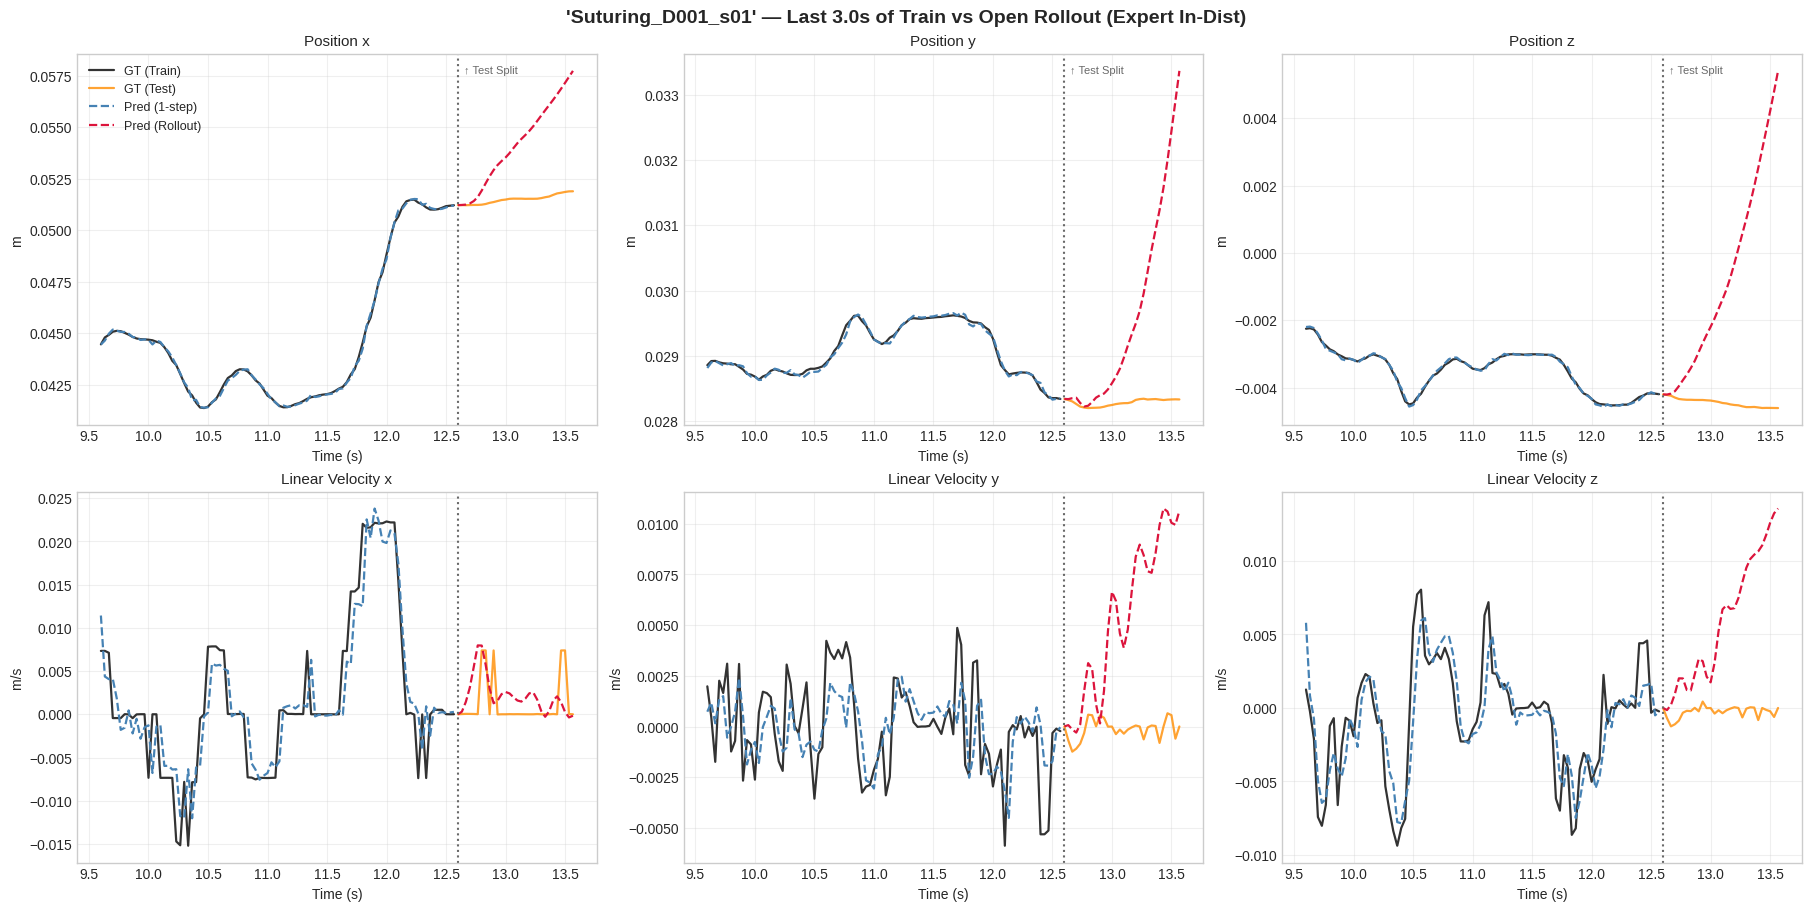

In [27]:
# ── Cell 10: Visualization & Analysis (JAX LSTM Compatible) ───────────────────
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax.core import unfreeze, freeze
from functools import partial

# =============================================================================
# 0. FIX ROLLOUT FUNCTION (Shape Tracer Fix)
# =============================================================================
@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout_fixed(model, params, x0_batched, n_steps):
    batch_size = x0_batched.shape[0]
    h0 = [(jnp.zeros((batch_size, model.hidden_size), dtype=jnp.float32),
           jnp.zeros((batch_size, model.hidden_size), dtype=jnp.float32))
          for _ in range(model.num_layers)]

    def step_fn(carry_and_state, _):
        carry, current_state = carry_and_state
        next_state, next_carry = model.apply(params, current_state, carry=carry, deterministic=True)
        return (next_carry, next_state), next_state

    _, trajectory = jax.lax.scan(step_fn, (h0, x0_batched), None, length=n_steps - 1)
    return jnp.concatenate([x0_batched[None, :], trajectory], axis=0)

def rollout_jax_fixed(wrapper, x0, n_steps):
    x0 = jnp.array(x0, dtype=jnp.float32)
    if x0.ndim == 1:
        x0 = x0[None, :]
    traj = _compiled_rollout_fixed(wrapper.model, wrapper.params, x0, n_steps)
    return np.array(traj[:, 0, :])

# =============================================================================
# 1. FIX PARAMETER SCOPING FOR ROLLOUT
# =============================================================================
params_unfrozen = unfreeze(final_params)
rollout_params_dict = {}
for k, v in params_unfrozen['params'].items():
    if k == 'LSTMCell_2':
        rollout_params_dict['LSTMCell_0'] = v
    elif k == 'LSTMCell_3':
        rollout_params_dict['LSTMCell_1'] = v
    else:
        rollout_params_dict[k] = v

rollout_params = freeze({'params': rollout_params_dict})
eval_model_rollout = EvalWrapper(dnn, rollout_params)

# =============================================================================
# 2. Prepare Data for Figure 1: Generate Predictions (EXPERT LOUO)
# =============================================================================
ref_trial = longest
states = np.array(ref_trial['states'])
T = len(states)
split_idx = int(T * 0.9)
t_boundary = split_idx * float(DT)

horizon_frames = min(T - split_idx, 30)
t_full = np.arange(T) * float(DT)
t_tr = t_full[:split_idx]
t_test = t_full[split_idx:split_idx + horizon_frames]

true_tr = states[:split_idx]
true_test = states[split_idx:split_idx + horizon_frames]

# --- 1-Step Prediction ---
xt_tr_raw = states[:split_idx-1]
xt_tr_n = (xt_tr_raw - state_mean) / state_std
pred_tr_n, _ = eval_model(xt_tr_n)
pred_tr_raw = np.array(pred_tr_n) * state_std + state_mean
pred_tr = np.vstack([states[0], pred_tr_raw])

# --- Rollout Prediction ---
x0_test_raw = states[split_idx]
x0_test_n = (x0_test_raw - state_mean) / state_std
pred_test_n = rollout_jax_fixed(eval_model_rollout, x0_test_n, horizon_frames)
pred_test = np.array(pred_test_n) * state_std + state_mean

# =============================================================================
# 3. FIGURE 1: Trajectory Rollouts
# =============================================================================
zoom_seconds = 3.0
zoom_frames = int(zoom_seconds / DT)
zoom_start = max(0, split_idx - zoom_frames)

t_tr_zoom = t_tr[zoom_start:]
true_tr_zoom = true_tr[zoom_start:]
pred_tr_zoom = pred_tr[zoom_start:]

labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]
linvel_idx = [6, 7, 8]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
fig.suptitle(f"'{ref_trial['name']}' — Last {zoom_seconds}s of Train vs Open Rollout (Expert In-Dist)",
             fontsize=14, fontweight='bold')

C_GT_TR, C_GT_ET = 'black', 'darkorange'
C_PR_TR, C_PR_ET = 'steelblue', 'crimson'

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes[row, j]

        ax.plot(t_tr_zoom, true_tr_zoom[:, idxs[j]], color=C_GT_TR, lw=1.6, alpha=0.80, label='GT (Train)')
        ax.plot(t_test, true_test[:, idxs[j]], color=C_GT_ET, lw=1.6, alpha=0.80, label='GT (Test)')

        ax.plot(t_tr_zoom, pred_tr_zoom[:, idxs[j]], '--', color=C_PR_TR, lw=1.6, label='Pred (1-step)')
        ax.plot(t_test, pred_test[:, idxs[j]], '--', color=C_PR_ET, lw=1.6, label='Pred (Rollout)')

        ax.axvline(x=t_boundary, color='dimgray', ls=':', lw=1.5)
        if row == 0:
            ax.text(t_boundary + 0.05, 0.97, '↑ Test Split', ha='left', va='top', transform=ax.get_xaxis_transform(), fontsize=8, color='dimgray')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(loc='best', fontsize=9)

plt.show()

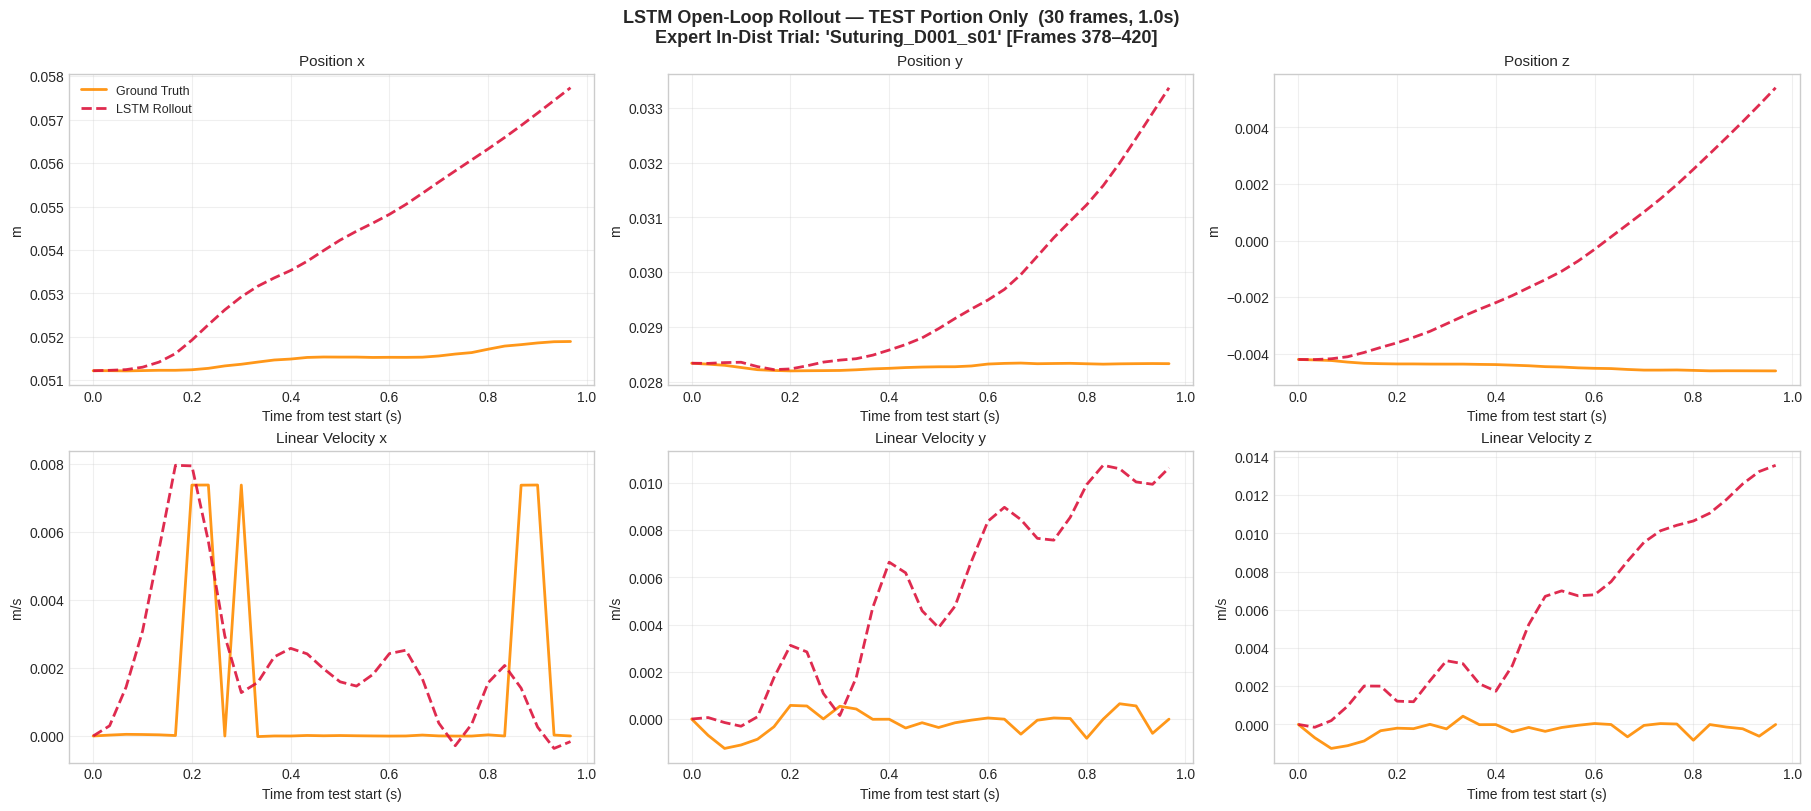

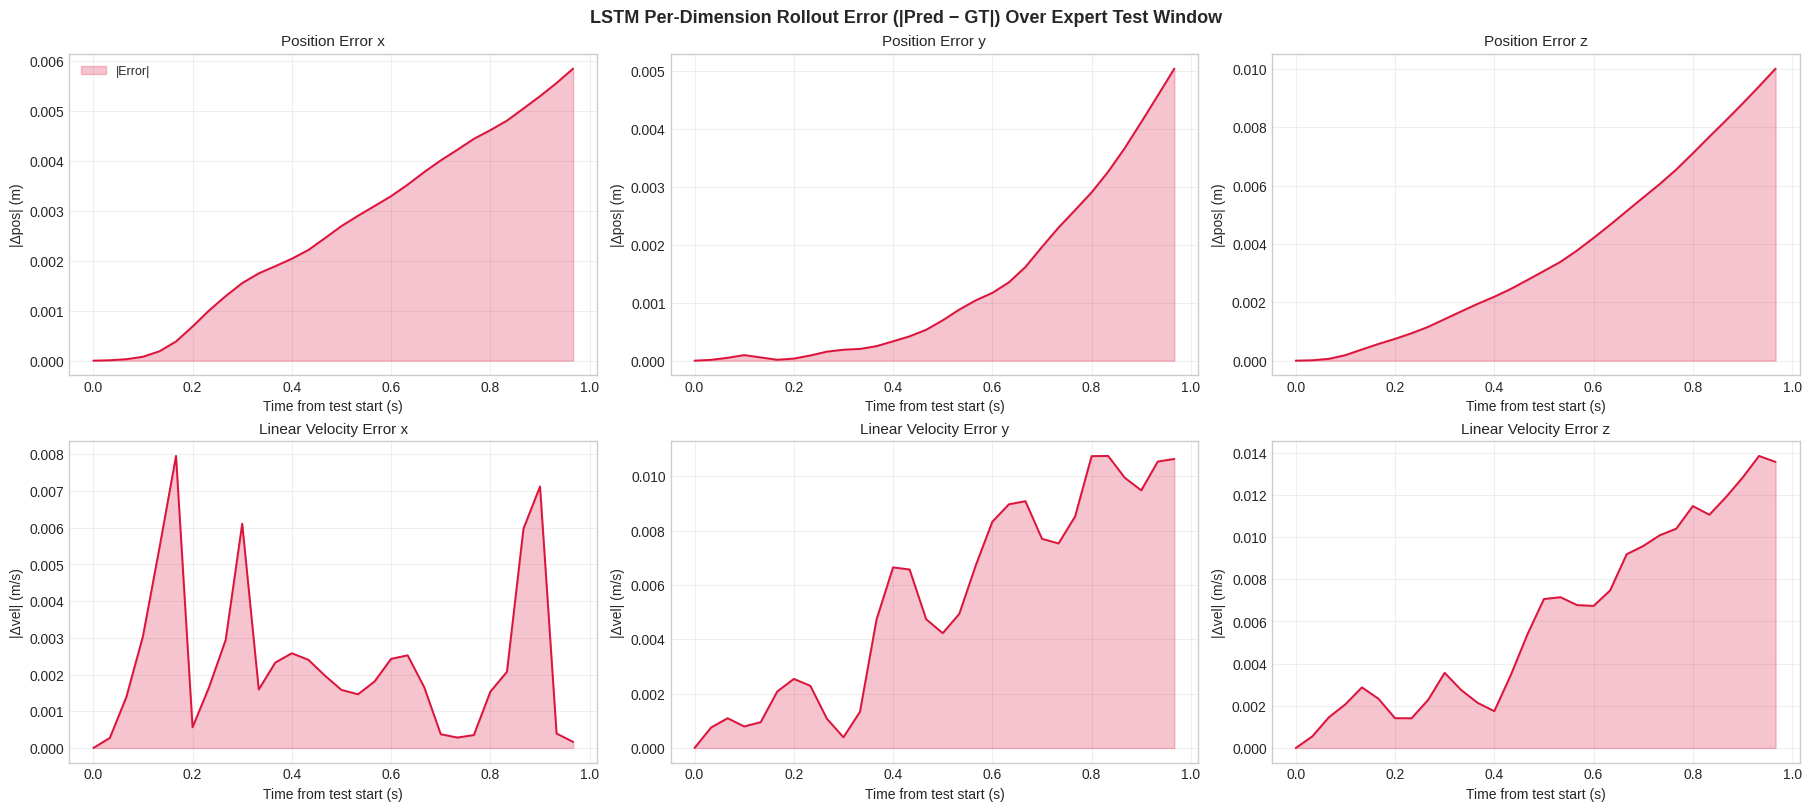

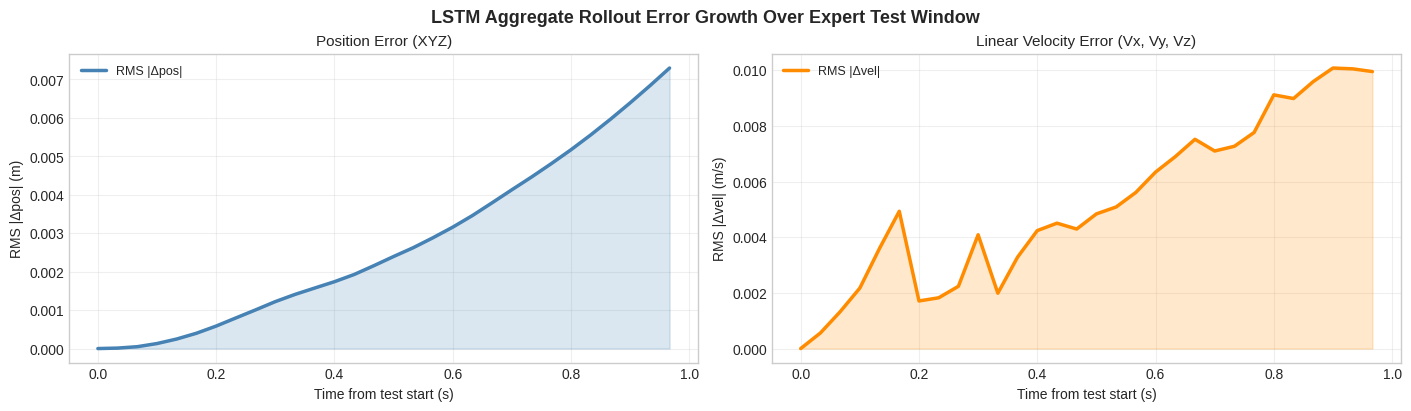

In [28]:
# ── Cell 11: Rollout Error Analysis & Visualization ──────────────────────────
import matplotlib.pyplot as plt
import numpy as np

T_total = len(states)
T_tr = split_idx
T_et = len(true_test)

t_test_relative = t_test - t_test[0]
labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]
linvel_idx = [6, 7, 8]

err_et = np.abs(pred_test - true_test)

# =============================================================================
# 1. FIGURE 3: Ground Truth vs Prediction
# =============================================================================
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig3.suptitle(
    f"LSTM Open-Loop Rollout — TEST Portion Only  ({T_et} frames, {T_et*float(DT):.1f}s)  \n"
    f"Expert In-Dist Trial: '{ref_trial['name']}' [Frames {T_tr}–{T_total-1}]",
    fontsize=13, fontweight='bold')

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes3[row, j]
        ax.plot(t_test_relative, true_test[:, idxs[j]], color='darkorange', lw=2.0, alpha=0.90, label='Ground Truth')
        ax.plot(t_test_relative, pred_test[:, idxs[j]], '--', color='crimson', lw=2.0, alpha=0.90, label='LSTM Rollout')
        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from test start (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0: ax.legend(fontsize=9)

plt.savefig('lstm_expert_test_traj_jigsaws.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 2. FIGURE 4: Per-Dimension Absolute Error Over Time
# =============================================================================
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig4.suptitle(f"LSTM Per-Dimension Rollout Error (|Pred − GT|) Over Expert Test Window", fontsize=13, fontweight='bold')

ylabels2 = ['|Δpos| (m)', '|Δvel| (m/s)']
for row, idxs, ylbl, kind in [(0, trans_idx, ylabels2[0], 'Position Error'),
                              (1, linvel_idx, ylabels2[1], 'Linear Velocity Error')]:
    for j in range(3):
        ax = axes4[row, j]
        ax.fill_between(t_test_relative, 0, err_et[:, idxs[j]], color='crimson', alpha=0.25, label='|Error|')
        ax.plot(t_test_relative, err_et[:, idxs[j]], color='crimson', lw=1.4)
        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from test start (s)')
        ax.set_ylabel(ylbl)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0: ax.legend(fontsize=9)

plt.savefig('lstm_expert_test_error_jigsaws.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 3. FIGURE 5: Aggregate RMS Error Curves
# =============================================================================
pos_err_t = np.sqrt(np.mean(err_et[:, :3] ** 2, axis=1))
vel_err_t = np.sqrt(np.mean(err_et[:, 6:9] ** 2, axis=1))

fig5, ax5 = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
fig5.suptitle('LSTM Aggregate Rollout Error Growth Over Expert Test Window', fontsize=13, fontweight='bold')

ax5[0].plot(t_test_relative, pos_err_t, color='steelblue', lw=2.5, label='RMS |Δpos|')
ax5[0].fill_between(t_test_relative, 0, pos_err_t, alpha=0.2, color='steelblue')
ax5[0].set_title('Position Error (XYZ)', fontsize=11)
ax5[0].set_xlabel('Time from test start (s)')
ax5[0].set_ylabel('RMS |Δpos| (m)')
ax5[0].grid(alpha=0.3)
ax5[0].legend(fontsize=9)

ax5[1].plot(t_test_relative, vel_err_t, color='darkorange', lw=2.5, label='RMS |Δvel|')
ax5[1].fill_between(t_test_relative, 0, vel_err_t, alpha=0.2, color='darkorange')
ax5[1].set_title('Linear Velocity Error (Vx, Vy, Vz)', fontsize=11)
ax5[1].set_xlabel('Time from test start (s)')
ax5[1].set_ylabel('RMS |Δvel| (m/s)')
ax5[1].grid(alpha=0.3)
ax5[1].legend(fontsize=9)

plt.savefig('lstm_expert_test_rms_error_jigsaws.png', dpi=150, bbox_inches='tight')
plt.show()

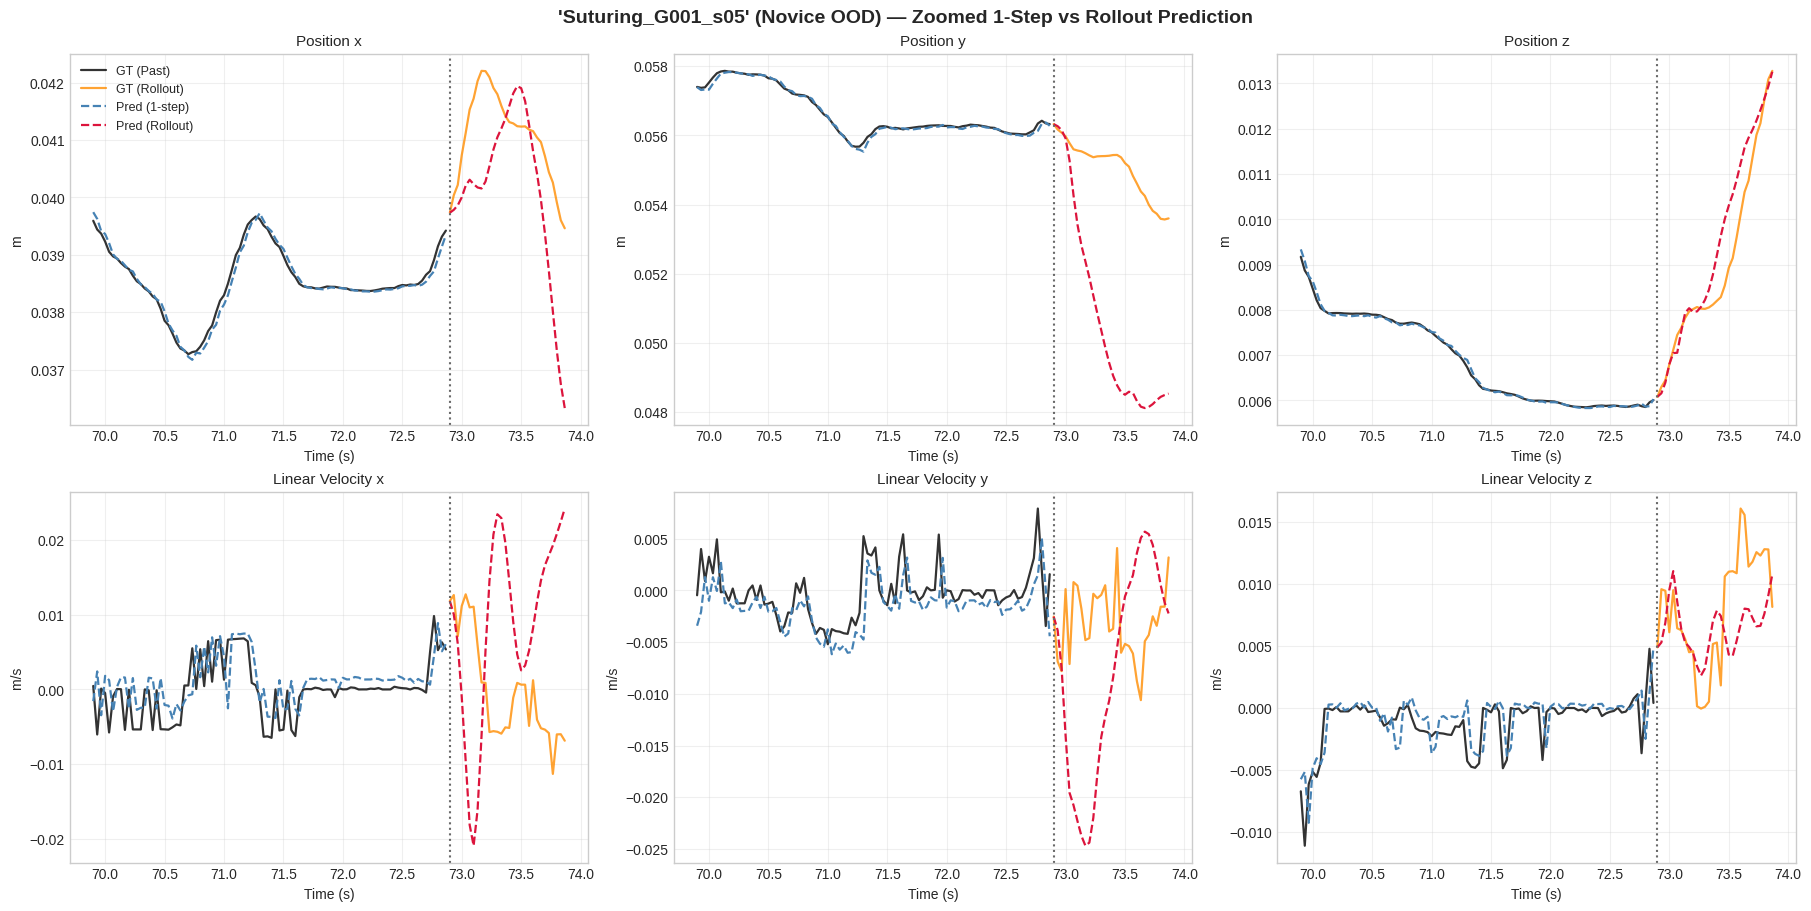

In [29]:
# ── Cell 12: Novice Trajectories (OOD) & Error Analysis (JAX LSTM) ───────────
import matplotlib.pyplot as plt
import numpy as np

# Focus on an Out-Of-Distribution (Novice) Trial
ood_ref_trial = max(nov_segs, key=lambda t: t['length'])
ood_states = np.array(ood_ref_trial['states'])
ood_total = len(ood_states)
ood_tr_len = int(ood_total * 0.9)
ood_t_boundary = ood_tr_len * float(DT)

ood_horizon_frames = min(ood_total - ood_tr_len, 30)

ood_t_full = np.arange(ood_total) * float(DT)
ood_t_tr = ood_t_full[:ood_tr_len]
ood_t_et = ood_t_full[ood_tr_len:ood_tr_len + ood_horizon_frames]

ood_true_tr = ood_states[:ood_tr_len]
ood_true_et = ood_states[ood_tr_len:ood_tr_len + ood_horizon_frames]

# --- 1-Step Prediction ---
ood_xt_tr_raw = ood_states[:ood_tr_len-1]
ood_xt_tr_n = (ood_xt_tr_raw - state_mean) / state_std
ood_pred_tr_n, _ = eval_model(ood_xt_tr_n)
ood_pred_tr_raw = np.array(ood_pred_tr_n) * state_std + state_mean
ood_pred_tr = np.vstack([ood_states[0], ood_pred_tr_raw])

# --- Rollout Prediction ---
ood_x0_test_raw = ood_states[ood_tr_len]
ood_x0_test_n = (ood_x0_test_raw - state_mean) / state_std
ood_pred_et_n = rollout_jax_fixed(eval_model_rollout, ood_x0_test_n, ood_horizon_frames)
ood_pred_et = np.array(ood_pred_et_n) * state_std + state_mean

labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]
linvel_idx = [6, 7, 8]

# ZOOM LOGIC for OOD Plot
zoom_seconds = 3.0
zoom_frames = int(zoom_seconds / DT)
zoom_start = max(0, ood_tr_len - zoom_frames)

ood_t_tr_zoom = ood_t_tr[zoom_start:]
ood_true_tr_zoom = ood_true_tr[zoom_start:]
ood_pred_tr_zoom = ood_pred_tr[zoom_start:]

fig_e, axes_e = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
fig_e.suptitle(f"'{ood_ref_trial['name']}' (Novice OOD) — Zoomed 1-Step vs Rollout Prediction",
               fontsize=14, fontweight='bold')

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes_e[row, j]
        ax.plot(ood_t_tr_zoom, ood_true_tr_zoom[:, idxs[j]], color='black', lw=1.6, alpha=0.80, label='GT (Past)')
        ax.plot(ood_t_et, ood_true_et[:, idxs[j]], color='darkorange', lw=1.6, alpha=0.80, label='GT (Rollout)')

        ax.plot(ood_t_tr_zoom, ood_pred_tr_zoom[:, idxs[j]], '--', color='steelblue', lw=1.6, label='Pred (1-step)')
        ax.plot(ood_t_et, ood_pred_et[:, idxs[j]], '--', color='crimson', lw=1.6, label='Pred (Rollout)')

        ax.axvline(x=ood_t_boundary, color='dimgray', ls=':', lw=1.5)
        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0: ax.legend(fontsize=9, loc='best')

plt.savefig('lstm_novice_ood_traj_jigsaws.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ── Cell 13: Final Summary Table + Rollout Horizon Errors (JAX LSTM Compatible) ───
import numpy as np

# Calculate Generalization Gap based on Filtered Means
gap_filt = (mse_ood_filt / mse_in_filt - 1) * 100

# Custom Eta Ratios (Novice OOD vs Expert Test) - Physical Velocity Error
c_eta_ratio_mean = c_eta_ood_mean / c_eta_in_mean if c_eta_in_mean > 0 else 0.0
c_eta_ratio_filt = c_eta_ood_filt / c_eta_in_filt if c_eta_in_filt > 0 else 0.0

W = 90
print('=' * W)
print('  FINAL SUMMARY TABLE — LSTM on JIGSAWS Suturing')
print('=' * W)
print(f'  Data source   : REAL JIGSAWS (Units: mm & mm/s)')
print(f'  Architecture  : LSTMPredictor (JAX/Flax Compiled)')
print()

rows_mse = [
    ('1-Step MSE Expert (Train)',           mse_tr_mean, mse_tr_filt),
    ('1-Step MSE Expert (Test, In-Dist)',   mse_in_mean, mse_in_filt),
    ('1-Step MSE Novice (Test, OOD)',       mse_ood_mean, mse_ood_filt),
]

print(f'  {"METRIC":<40} | {"RAW MEAN":<15} | {"FILTERED MEAN (Bottom 99%)":<25}')
print('-' * W)

for name, mean_val, filt_val in rows_mse:
    print(f'  {name:<40} | {float(mean_val):<15.4e} | {float(filt_val):<25.4e}')

print('-' * W)
print(f'  {"Generalization Gap (Novice vs Expert)":<40} | {gap_filt:>11.2f} %')
print('-' * W)

print(f'  {"Custom η (Physical Vel Error |dq/dt|)":<40} | {"":<15} | {"":<25}')
print(f'  {"  Expert (Test In-Dist)":<40} | {float(c_eta_in_mean):<15.6f} | {float(c_eta_in_filt):<25.6f}')
print(f'  {"  Novice (Test OOD)":<40} | {float(c_eta_ood_mean):<15.6f} | {float(c_eta_ood_filt):<25.6f}')
print(f'  {"  Novice/Expert Custom η Ratio":<40} | {float(c_eta_ratio_mean):<13.2f} × | {float(c_eta_ratio_filt):<13.2f} ×')

print('=' * W)
print('  Notes:')
print('  • Train on EXPERT subjects, test on NOVICE subjects (OOD).')
print('  • "Filtered Mean" mathematically drops the top 1% of frames (extreme prediction outliers) before averaging.')
print('=' * W)

  FINAL SUMMARY TABLE — LSTM on JIGSAWS Suturing
  Data source   : REAL JIGSAWS (Units: mm & mm/s)
  Architecture  : LSTMPredictor (JAX/Flax Compiled)

  METRIC                                   | RAW MEAN        | FILTERED MEAN (Bottom 99%)
------------------------------------------------------------------------------------------
  1-Step MSE Expert (Train)                | 3.1176e-01      | 2.8741e-01               
  1-Step MSE Expert (Test, In-Dist)        | 4.8608e-01      | 4.4939e-01               
  1-Step MSE Novice (Test, OOD)            | 3.2053e+09      | 8.7126e-01               
------------------------------------------------------------------------------------------
  Generalization Gap (Novice vs Expert)    |       93.88 %
------------------------------------------------------------------------------------------
  Custom η (Physical Vel Error |dq/dt|)    |                 |                          
    Expert (Test In-Dist)                  | 0.618811        | 0.57516

In [31]:
# ── Cell 14: Compute Dataset-Wide 1-Second Rollout Errors ────────────────────
import numpy as np

# =============================================================================
# 6. Compute Dataset-Wide 1-Second Rollout Errors
# =============================================================================
def compute_dataset_rollout_error(eval_wrapper, trials, scale, horizon_frames=30, step_size=30):
    all_window_errors = []

    for t in trials:
        raw_states = t['states']
        T = len(raw_states)

        for start_idx in range(0, T - horizon_frames, step_size):
            x0_raw = raw_states[start_idx]
            true_traj = raw_states[start_idx : start_idx + horizon_frames]

            # 1. Normalize start state
            x0_n = (x0_raw - state_mean) / state_std

            # 2. Use the fixed rollout function
            pred_traj_n = rollout_jax_fixed(eval_wrapper, x0_n, horizon_frames)

            # 3. Un-normalize back to physical space
            pred_traj = np.array(pred_traj_n) * state_std + state_mean

            # 4. Scaled MSE
            err = ((pred_traj - true_traj) / scale)**2
            window_mse = np.mean(err)
            all_window_errors.append(float(window_mse))

    all_window_errors = np.array(all_window_errors)

    # Remove top 1% outliers
    threshold = np.percentile(all_window_errors, 99.0)
    filtered_errors = all_window_errors[all_window_errors <= threshold]

    raw_mean = float(np.mean(all_window_errors))
    filtered_mean = float(np.mean(filtered_errors))

    return raw_mean, filtered_mean

print("\nComputing 1-second Rollout Errors across the entire dataset...")
scale_array = np.array(state_std, dtype=np.float32)

ro_tr_mean, ro_tr_filt = compute_dataset_rollout_error(eval_model_rollout, exp_train, scale_array)
ro_in_mean, ro_in_filt = compute_dataset_rollout_error(eval_model_rollout, exp_test, scale_array)
ro_ood_mean, ro_ood_filt = compute_dataset_rollout_error(eval_model_rollout, nov_segs, scale_array)

W = 90
print(f'\n{"="*W}')
print(f'{"1-SECOND ROLLOUT SCALED MSE (Dataset-Wide)":^{W}}')
print(f'{"="*W}')
print(f'  Train (Expert)            : Raw Mean {ro_tr_mean:.4e} | Filtered Mean {ro_tr_filt:.4e}')
print(f'  Test (Expert In-Dist)     : Raw Mean {ro_in_mean:.4e} | Filtered Mean {ro_in_filt:.4e}')
print(f'  Test (Novice OOD)         : Raw Mean {ro_ood_mean:.4e} | Filtered Mean {ro_ood_filt:.4e}')
print(f'{"="*W}\n')


Computing 1-second Rollout Errors across the entire dataset...

                        1-SECOND ROLLOUT SCALED MSE (Dataset-Wide)                        
  Train (Expert)            : Raw Mean 8.0601e+00 | Filtered Mean 6.5125e+00
  Test (Expert In-Dist)     : Raw Mean 5.4410e+00 | Filtered Mean 5.1015e+00
  Test (Novice OOD)         : Raw Mean 2.5913e+07 | Filtered Mean 8.2006e+00

